<a href="https://colab.research.google.com/github/medistlabo/TCGA_Practice/blob/main/tcga_practice_day14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "patient": ["P1","P2","P3","P4","P5","P6","P7","P8","P9","P10","P11","P12"],
    "expression": [5,12,18,25,30,7,40,22,15,35,28,10],
    "survival_month": [50,40,35,20,15,45,10,25,38,12,18,48],
    "status": [0,0,1,1,1,0,1,1,0,1,1,0]
}

df = pd.DataFrame(data)

df.head()

,patient,expression,survival_month,status
0,P1,5,50,0
1,P2,12,40,0
2,P3,18,35,1
3,P4,25,20,1
4,P5,30,15,1


In [10]:
df["group_median"] = df['expression'].apply(
    lambda x: "High" if x >= df["expression"].median()
    else "Low"
)

df.head()

,patient,expression,survival_month,status,group_median
0,P1,5,50,0,Low
1,P2,12,40,0,Low
2,P3,18,35,1,Low
3,P4,25,20,1,High
4,P5,30,15,1,High


In [12]:
df.groupby("group_median")["status"].mean()

,status
group_median,
High,1.000000
Low,0.166667


In [29]:
df["group_median"].value_counts()

,count
group_median,
Low,6
High,6


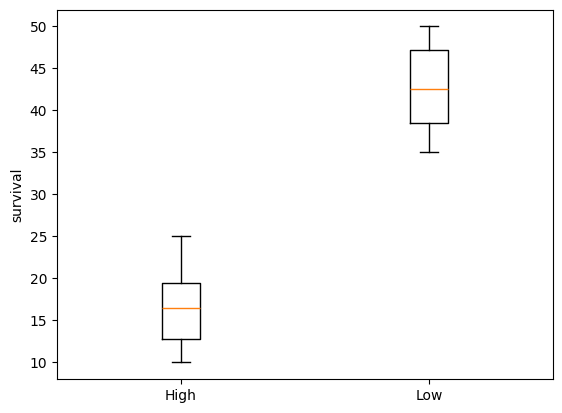

In [21]:
high_survival_month = df[df["group_median"] == "High"]["survival_month"]
low_survival_month = df[df["group_median"] == "Low"]["survival_month"]

plt.boxplot([high_survival_month, low_survival_month])

plt.xticks([1, 2], ["High", "Low"])
plt.ylabel("survival")

plt.show()

In [22]:
df[df["status"] == 1]

,patient,expression,survival_month,status,group_median
2,P3,18,35,1,Low
3,P4,25,20,1,High
4,P5,30,15,1,High
6,P7,40,10,1,High
7,P8,22,25,1,High
9,P10,35,12,1,High
10,P11,28,18,1,High


In [31]:
df[(df["status"] == 1)& (df["group_median"] == "High")]

,patient,expression,survival_month,status,group_median
3,P4,25,20,1,High
4,P5,30,15,1,High
6,P7,40,10,1,High
7,P8,22,25,1,High
9,P10,35,12,1,High
10,P11,28,18,1,High


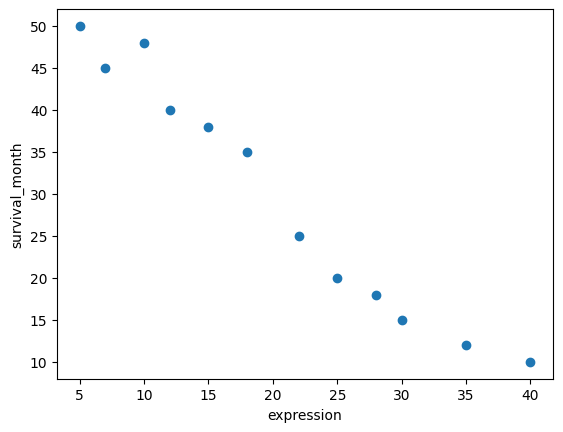

In [25]:
plt.scatter(df["expression"], df["survival_month"])

plt.xlabel("expression")
plt.ylabel("survival_month")

plt.show()

In [26]:
df["expression"].corr(df["survival_month"])

np.float64(-0.9793179103389704)